# ICASSP 2025 — BG60K Exploratory Data Analysis

In [1]:
import os
import io
import random
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

DATA_DIR  = Path('../data/ICASSP2025-BG60k')
TRAIN_ZIPS = [DATA_DIR / f'bg60k_imgs_{i}.zip' for i in range(10)]
TEST_ZIP   = DATA_DIR / 'bg1k_imgs.zip'
TRAIN_INFO = DATA_DIR / 'bg60k_info.txt'
TEST_INFO  = DATA_DIR / 'bg1k_info.txt'
PAIR_INFO  = DATA_DIR / 'bgpair_info.txt'

print('Data dir exists:', DATA_DIR.exists())
print('Files present:')
for f in sorted(DATA_DIR.iterdir()):
    size_mb = f.stat().st_size / 1024**2
    print(f'  {f.name:<30} {size_mb:>8.1f} MB')

Data dir exists: True
Files present:
  bg1k_imgs.zip                     525.2 MB
  bg1k_info.txt                       0.0 MB
  bg60k_imgs_0.zip                 2396.0 MB
  bg60k_imgs_1.zip                 2467.8 MB
  bg60k_imgs_2.zip                 2441.3 MB
  bg60k_imgs_3.zip                 2429.8 MB
  bg60k_imgs_4.zip                 2413.6 MB
  bg60k_imgs_5.zip                 2475.8 MB
  bg60k_imgs_6.zip                 2475.8 MB
  bg60k_imgs_7.zip                 2416.2 MB
  bg60k_imgs_8.zip                 2423.9 MB
  bg60k_imgs_9.zip                 2427.4 MB
  bg60k_info.txt                      1.5 MB
  bgpair_info.txt                     0.0 MB


## 1. Dataset Structure

The dataset ships as **flat zip archives** (no CSV labels — labels are in plain `.txt` files).

| File | Role |
|---|---|
| `bg60k_imgs_0.zip` … `bg60k_imgs_9.zip` | Training images (10 shards) |
| `bg60k_info.txt` | Training labels: `filename\tcategory_name` |
| `bg1k_imgs.zip` | Test images |
| `bg1k_info.txt` | Test labels: `filename\tcategory_name` |
| `bgpair_info.txt` | Similarity pairs: `img_a\timg_b\tcategory_name` |

In [2]:
# Load info files into DataFrames
train_df = pd.read_csv(TRAIN_INFO, sep='\t', header=None, names=['filename', 'category'])
test_df  = pd.read_csv(TEST_INFO,  sep='\t', header=None, names=['filename', 'category'])
pair_df  = pd.read_csv(PAIR_INFO,  sep='\t', header=None, names=['img_a', 'img_b', 'category'])

print('=== TRAIN INFO ===')
print(f'Shape: {train_df.shape}')
display(train_df.head())

print('\n=== TEST INFO ===')
print(f'Shape: {test_df.shape}')
display(test_df.head())

print('\n=== PAIR INFO ===')
print(f'Shape: {pair_df.shape}')
display(pair_df.head())

=== TRAIN INFO ===
Shape: (63293, 2)


,filename,category
0,0.png,Vitamins or Minerals for Infants and Toddlers
1,1.png,Liquor
2,2.png,Bluetooth or Wireless Headphones
3,3.png,Women shoulder or crossbody bag
4,4.png,Speakers or Audio



=== TEST INFO ===
Shape: (1000, 2)


,filename,category
0,0.png,refrigerator
1,1.png,refrigerator
2,2.png,refrigerator
3,3.png,refrigerator
4,4.png,refrigerator



=== PAIR INFO ===
Shape: (800, 3)


,img_a,img_b,category
0,0.png,1.png,refrigerator
1,0.png,2.png,refrigerator
2,3.png,4.png,refrigerator
3,3.png,5.png,refrigerator
4,3.png,1.png,refrigerator


## 2. Image Counts & File Consistency

In [3]:
# Count images inside each zip
train_disk = 0
per_zip = []
for zp in TRAIN_ZIPS:
    with zipfile.ZipFile(zp) as z:
        imgs = [f for f in z.namelist() if f.endswith('.png')]
        per_zip.append(len(imgs))
        train_disk += len(imgs)

with zipfile.ZipFile(TEST_ZIP) as z:
    test_disk = len([f for f in z.namelist() if f.endswith('.png')])

print('=== Image Counts ===')
print(f'Train images on disk : {train_disk:,}  (across 10 zips)')
print(f'Train rows in CSV    : {len(train_df):,}')
print(f'Disk - CSV diff      : {train_disk - len(train_df)}')
print()
print(f'Test images on disk  : {test_disk:,}')
print(f'Test rows in CSV     : {len(test_df):,}')
print(f'Disk - CSV diff      : {test_disk - len(test_df)}')
print()
print('Images per train shard:', per_zip)

print('\n=== Nulls & Duplicates ===')
for name, df in [('train', train_df), ('test', test_df), ('pair', pair_df)]:
    print(f'{name}: nulls={df.isnull().sum().sum()}  duplicates={df.duplicated().sum()}')

=== Image Counts ===
Train images on disk : 63,296  (across 10 zips)
Train rows in CSV    : 63,293
Disk - CSV diff      : 3

Test images on disk  : 1,055
Test rows in CSV     : 1,000
Disk - CSV diff      : 55

Images per train shard: [6330, 6330, 6333, 6329, 6329, 6329, 6329, 6329, 6329, 6329]

=== Nulls & Duplicates ===
train: nulls=0  duplicates=0
test: nulls=0  duplicates=0
pair: nulls=0  duplicates=0


## 3. Category Distribution — Train

In [4]:
train_counts = train_df['category'].value_counts()
counts = train_counts.values

print(f'Unique categories (train): {len(train_counts):,}')
print(f'Min / Max / Mean / Median: {counts.min()} / {counts.max()} / {counts.mean():.1f} / {int(np.median(counts))}')
print(f'Class imbalance ratio    : {counts.max() / counts.min():.0f}x')
print()
print('Top 10 categories:')
display(train_counts.head(10).rename('count').to_frame())
print('Bottom 10 categories:')
display(train_counts.tail(10).rename('count').to_frame())

Unique categories (train): 1,981
Min / Max / Mean / Median: 1 / 1427 / 32.0 / 8
Class imbalance ratio    : 1427x

Top 10 categories:


,count
category,
cell phone,1427
Men casual shoes,1304
Liquor,1268
running shoes,933
national watch,851
Sports and casual shoes,723
Women shoulder or crossbody bag,655
Bluetooth or Wireless Headphones,610
decorative ornaments,492


Bottom 10 categories:


,count
category,
360 panoramic image,1
teen bike,1
second hand memory,1
pet accessories,1
Balcony guardrail or window guardrail,1
Air Cushion CC or CC Cream,1
double eyelid patch,1
circuit switch toy,1
Fake eyelashes,1


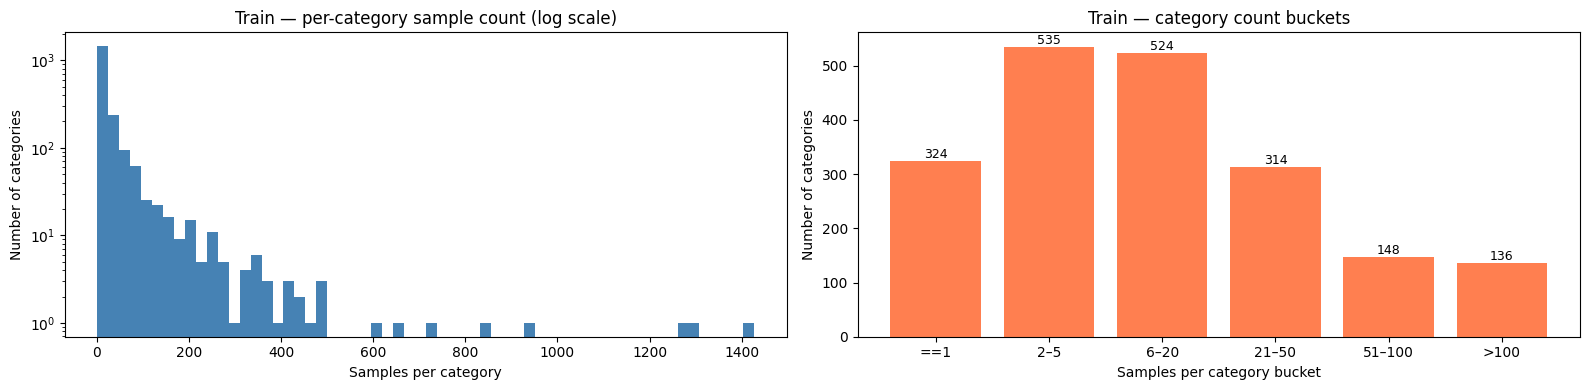

Bucket counts: {'==1': 324, '2–5': 535, '6–20': 524, '21–50': 314, '51–100': 148, '>100': 136}


In [5]:
# Bucket distribution of per-category sample counts
buckets = {'==1': 0, '2–5': 0, '6–20': 0, '21–50': 0, '51–100': 0, '>100': 0}
for v in counts:
    if v == 1:        buckets['==1'] += 1
    elif v <= 5:      buckets['2–5'] += 1
    elif v <= 20:     buckets['6–20'] += 1
    elif v <= 50:     buckets['21–50'] += 1
    elif v <= 100:    buckets['51–100'] += 1
    else:             buckets['>100'] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Histogram of per-category counts
axes[0].hist(counts, bins=60, color='steelblue', log=True)
axes[0].set_title('Train — per-category sample count (log scale)')
axes[0].set_xlabel('Samples per category'); axes[0].set_ylabel('Number of categories')

# Bucket bar chart
axes[1].bar(buckets.keys(), buckets.values(), color='coral')
axes[1].set_title('Train — category count buckets')
axes[1].set_xlabel('Samples per category bucket'); axes[1].set_ylabel('Number of categories')
for i, (k, v) in enumerate(buckets.items()):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print('Bucket counts:', buckets)

## 4. Category Distribution — Test

In [6]:
test_counts = test_df['category'].value_counts()

print(f'Unique categories (test): {len(test_counts)}')
print(f'Min / Max / Mean: {test_counts.min()} / {test_counts.max()} / {test_counts.mean():.1f}')
print()

# Check overlap
train_cats = set(train_df['category'])
test_cats  = set(test_df['category'])
print(f'Test categories also in train: {len(test_cats & train_cats)} / {len(test_cats)}')
print(f'Test categories NOT in train : {test_cats - train_cats}')
print()
print('Top 15 test categories:')
display(test_counts.head(15).rename('count').to_frame())

Unique categories (test): 213
Min / Max / Mean: 2 / 28 / 4.7

Test categories also in train: 213 / 213
Test categories NOT in train : set()

Top 15 test categories:


,count
category,
decorative ornaments,28
refrigerator,13
fabric sofa,13
dining table,12
Storage Box,11
Men T-shirt,10
washing machine,10
men backpack,10
Set or gift box,10


## 5. bgpair — Similarity Pair Analysis

In [7]:
pair_counts = pair_df['category'].value_counts()
pair_imgs   = set(pair_df['img_a']) | set(pair_df['img_b'])

print(f'Total pairs              : {len(pair_df):,}')
print(f'Unique categories in pairs: {len(pair_counts)}')
print(f'Unique images in pairs   : {len(pair_imgs)}')

# Check if pair images are a subset of test images
with zipfile.ZipFile(TEST_ZIP) as z:
    test_imgs_on_disk = set(f.split('/')[-1] for f in z.namelist() if f.endswith('.png'))
print(f'Pair images found in test zip: {len(pair_imgs & test_imgs_on_disk)} / {len(pair_imgs)}')
print(f'Pair images NOT in test zip  : {pair_imgs - test_imgs_on_disk}')
print()
print('Top 10 most-paired categories:')
display(pair_counts.head(10).rename('pair_count').to_frame())

Total pairs              : 800
Unique categories in pairs: 270
Unique images in pairs   : 1193
Pair images found in test zip: 1000 / 1193
Pair images NOT in test zip  : {'1152.png', '1138.png', '1022.png', '1037.png', '1010.png', '1038.png', '1121.png', '1036.png', '1128.png', '1106.png', '1030.png', '1055.png', '1054.png', '1020.png', '1116.png', '1091.png', '1184.png', '1112.png', '1067.png', '1090.png', '1098.png', '1073.png', '1089.png', '1176.png', '1093.png', '1066.png', '1168.png', '1163.png', '1137.png', '1034.png', '1149.png', '1076.png', '1046.png', '1145.png', '1052.png', '1101.png', '1143.png', '1125.png', '1161.png', '1147.png', '1084.png', '1095.png', '1071.png', '1074.png', '1188.png', '1113.png', '1142.png', '1174.png', '1072.png', '1009.png', '1040.png', '1001.png', '1085.png', '1159.png', '1130.png', '1164.png', '1165.png', '1153.png', '1166.png', '1017.png', '1148.png', '1189.png', '1107.png', '1041.png', '1077.png', '1044.png', '1029.png', '1129.png', '1186.png', '1

,pair_count
category,
refrigerator,35
decorative ornaments,33
dining table,13
fabric sofa,10
Women shoulder or crossbody bag,7
Set or gift box,7
Storage Box,7
black tea,6
Sports and casual shoes,6


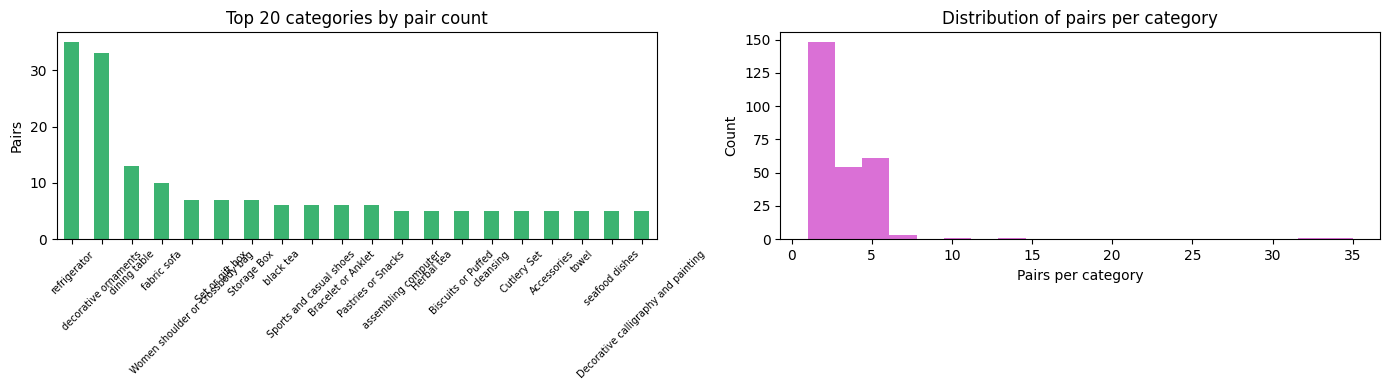

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pair_counts.head(20).plot(kind='bar', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Top 20 categories by pair count')
axes[0].set_xlabel(''); axes[0].set_ylabel('Pairs')
axes[0].tick_params(axis='x', labelrotation=45, labelsize=7)

axes[1].hist(pair_counts.values, bins=20, color='orchid')
axes[1].set_title('Distribution of pairs per category')
axes[1].set_xlabel('Pairs per category'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Image Properties (Sampled)

In [9]:
random.seed(42)

def sample_image_stats(zip_path, n=100):
    with zipfile.ZipFile(zip_path) as z:
        files = [f for f in z.namelist() if f.endswith('.png')]
        sample = random.sample(files, min(n, len(files)))
        widths, heights, sizes, modes = [], [], [], set()
        for f in sample:
            data = z.read(f)
            sizes.append(len(data) / 1024)
            img = Image.open(io.BytesIO(data))
            widths.append(img.width)
            heights.append(img.height)
            modes.add(img.mode)
    return widths, heights, sizes, modes

# Sample from first training zip and test zip
tw, th, ts, tmodes = sample_image_stats(TRAIN_ZIPS[0], n=200)
ew, eh, es, emodes = sample_image_stats(TEST_ZIP,      n=200)

print('=== Train images (200-sample) ===')
print(f'Width  — min={min(tw)} max={max(tw)} mean={np.mean(tw):.0f}')
print(f'Height — min={min(th)} max={max(th)} mean={np.mean(th):.0f}')
print(f'Size   — min={min(ts):.1f} KB  max={max(ts):.1f} KB  mean={np.mean(ts):.1f} KB')
print(f'Modes  — {tmodes}')

print('\n=== Test images (200-sample) ===')
print(f'Width  — min={min(ew)} max={max(ew)} mean={np.mean(ew):.0f}')
print(f'Height — min={min(eh)} max={max(eh)} mean={np.mean(eh):.0f}')
print(f'Size   — min={min(es):.1f} KB  max={max(es):.1f} KB  mean={np.mean(es):.1f} KB')
print(f'Modes  — {emodes}')

=== Train images (200-sample) ===
Width  — min=800 max=800 mean=800
Height — min=800 max=800 mean=800
Size   — min=24.2 KB  max=1424.5 KB  mean=383.9 KB
Modes  — {'P', 'RGB', 'RGBA'}

=== Test images (200-sample) ===
Width  — min=800 max=800 mean=800
Height — min=800 max=800 mean=800
Size   — min=46.3 KB  max=1583.7 KB  mean=511.0 KB
Modes  — {'RGB', 'RGBA'}


Train file sizes (KB): min=12.1  max=1738.3  mean=414.5
Test  file sizes (KB): min=29.5  max=1590.9  mean=524.2


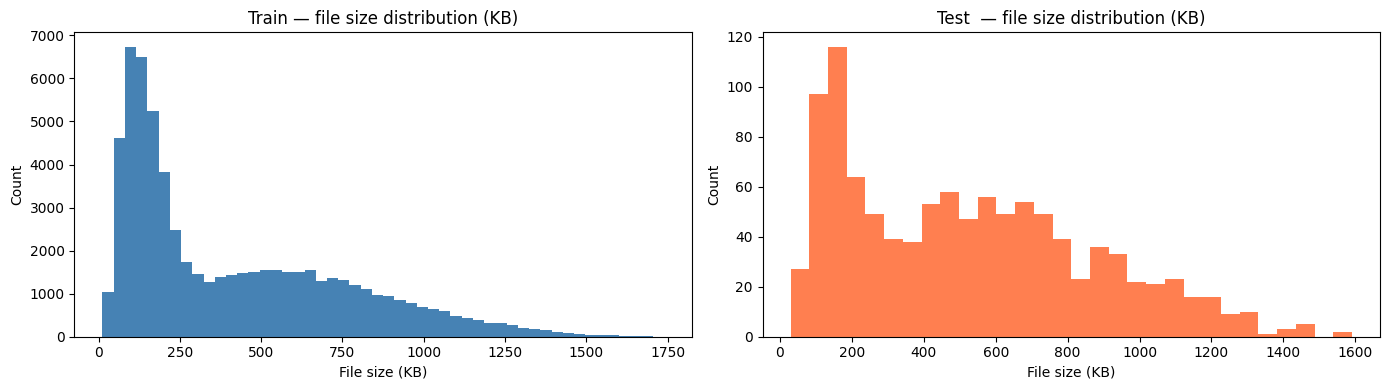

In [10]:
# Full file size distribution across ALL train zips (no decompression needed)
all_sizes_kb = []
for zp in TRAIN_ZIPS:
    with zipfile.ZipFile(zp) as z:
        for info in z.infolist():
            if info.filename.endswith('.png') and info.file_size > 0:
                all_sizes_kb.append(info.file_size / 1024)

with zipfile.ZipFile(TEST_ZIP) as z:
    test_sizes_kb = [i.file_size / 1024 for i in z.infolist()
                     if i.filename.endswith('.png') and i.file_size > 0]

print(f'Train file sizes (KB): min={min(all_sizes_kb):.1f}  max={max(all_sizes_kb):.1f}  mean={np.mean(all_sizes_kb):.1f}')
print(f'Test  file sizes (KB): min={min(test_sizes_kb):.1f}  max={max(test_sizes_kb):.1f}  mean={np.mean(test_sizes_kb):.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(all_sizes_kb,  bins=50, color='steelblue');  axes[0].set_title('Train — file size distribution (KB)')
axes[1].hist(test_sizes_kb, bins=30, color='coral');       axes[1].set_title('Test  — file size distribution (KB)')
for ax in axes:
    ax.set_xlabel('File size (KB)'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

## 7. Sample Images

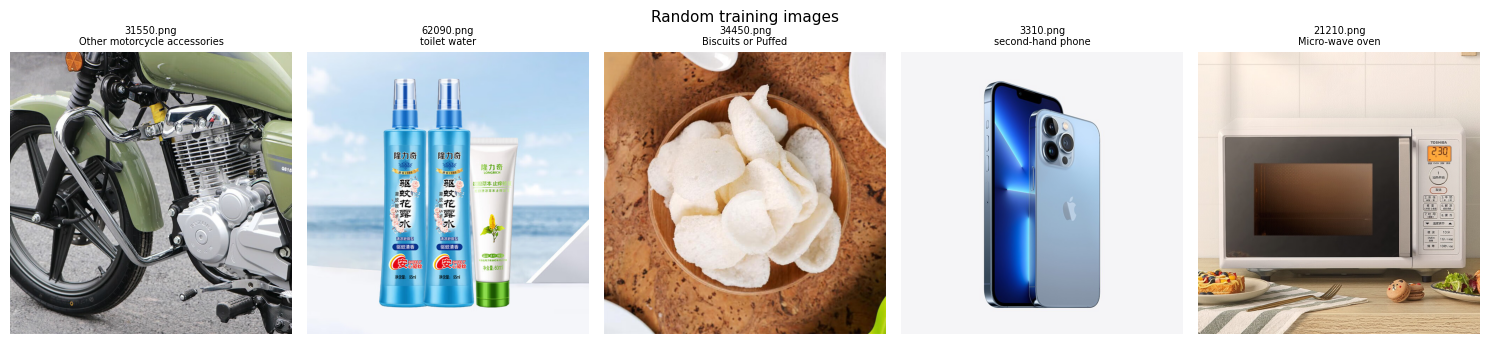

In [11]:
# Show 5 random training images from the first shard
random.seed(0)
N = 5

with zipfile.ZipFile(TRAIN_ZIPS[0]) as z:
    files = [f for f in z.namelist() if f.endswith('.png')]
    sample = random.sample(files, N)
    images = [Image.open(io.BytesIO(z.read(f))).convert('RGB') for f in sample]

# Look up labels
fname_to_cat = dict(zip(train_df['filename'], train_df['category']))

fig, axes = plt.subplots(1, N, figsize=(N * 3, 3.5))
for ax, img, fname in zip(axes, images, sample):
    bare = fname.split('/')[-1]
    cat  = fname_to_cat.get(bare, '?')
    ax.imshow(img)
    ax.set_title(f'{bare}\n{cat}', fontsize=7, wrap=True)
    ax.axis('off')
plt.suptitle('Random training images', fontsize=11)
plt.tight_layout()
plt.show()

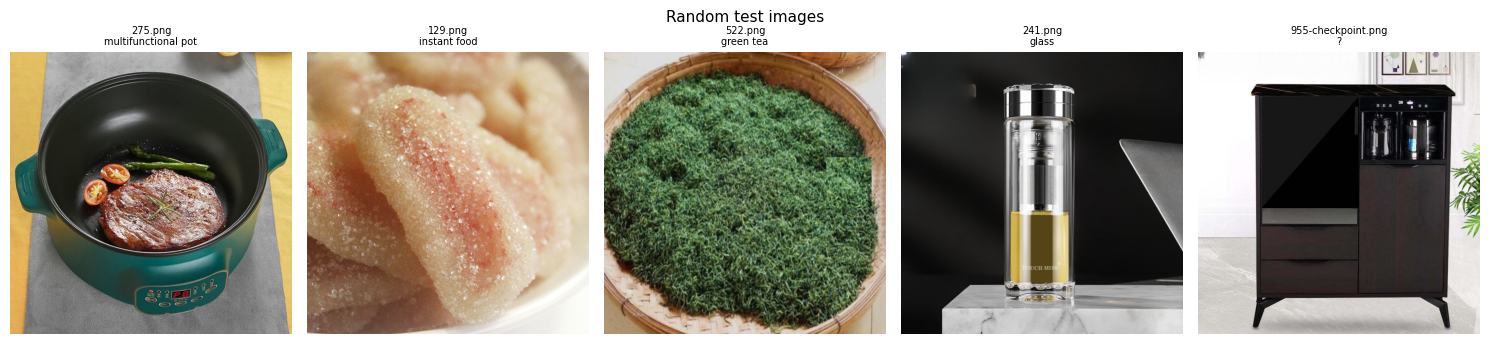

In [12]:
# Show 5 test images with their categories
random.seed(1)
fname_to_test_cat = dict(zip(test_df['filename'], test_df['category']))

with zipfile.ZipFile(TEST_ZIP) as z:
    tfiles = [f for f in z.namelist() if f.endswith('.png')]
    tsample = random.sample(tfiles, N)
    timages = [Image.open(io.BytesIO(z.read(f))).convert('RGB') for f in tsample]

fig, axes = plt.subplots(1, N, figsize=(N * 3, 3.5))
for ax, img, fname in zip(axes, timages, tsample):
    bare = fname.split('/')[-1]
    cat  = fname_to_test_cat.get(bare, '?')
    ax.imshow(img)
    ax.set_title(f'{bare}\n{cat}', fontsize=7, wrap=True)
    ax.axis('off')
plt.suptitle('Random test images', fontsize=11)
plt.tight_layout()
plt.show()

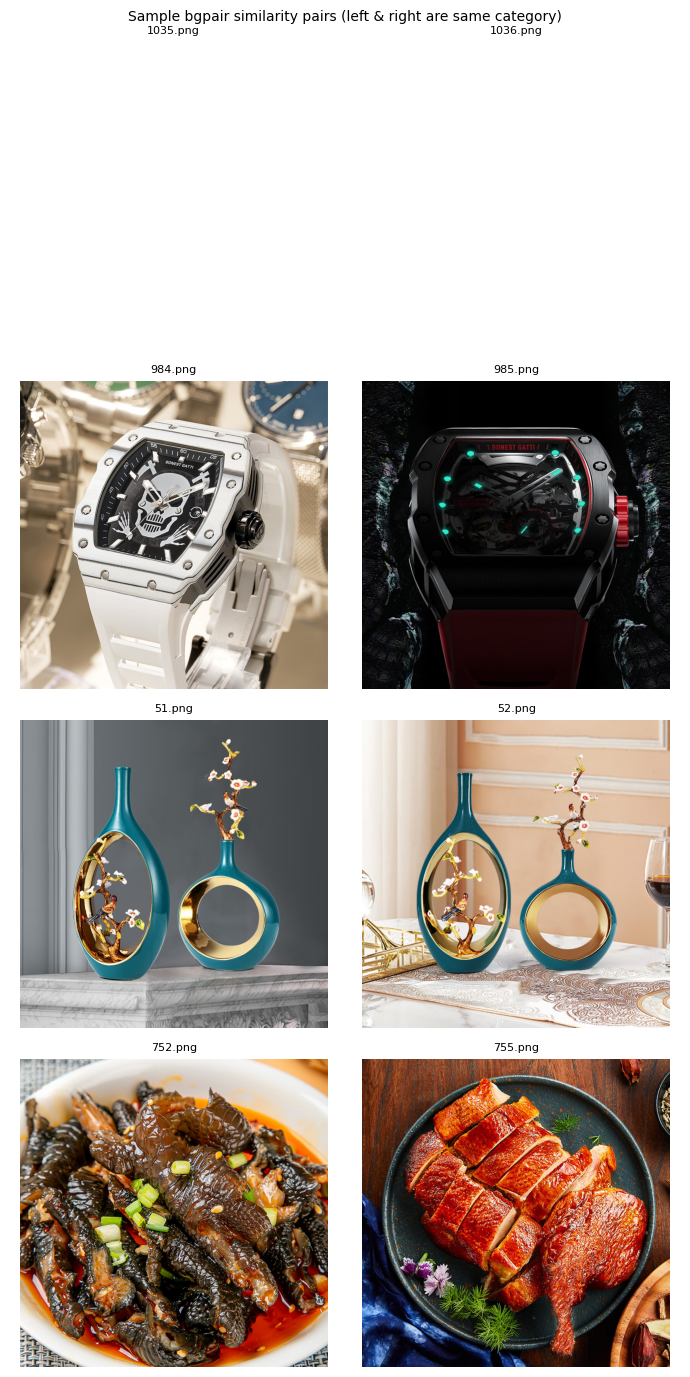

In [13]:
# Visualise 4 similarity pairs from bgpair_info
random.seed(42)
sampled_pairs = pair_df.sample(4, random_state=42)

with zipfile.ZipFile(TEST_ZIP) as z:
    zip_contents = {f.split('/')[-1]: f for f in z.namelist() if f.endswith('.png')}

    fig, axes = plt.subplots(4, 2, figsize=(7, 14))
    for row, (_, pair) in enumerate(sampled_pairs.iterrows()):
        for col, key in enumerate(['img_a', 'img_b']):
            fname = pair[key]
            zname = zip_contents.get(fname)
            if zname:
                img = Image.open(io.BytesIO(z.read(zname))).convert('RGB')
                axes[row][col].imshow(img)
            axes[row][col].set_title(f'{fname}', fontsize=8)
            axes[row][col].axis('off')
        axes[row][0].set_ylabel(pair['category'], fontsize=7, rotation=0, labelpad=60, va='center')

plt.suptitle('Sample bgpair similarity pairs (left & right are same category)', fontsize=10)
plt.tight_layout()
plt.show()

## 8. EDA Summary

### Dataset Overview

| | Train | Test |
|---|---|---|
| Images on disk | 63,296 (10 shards) | 1,055 |
| Rows in info file | 63,293 | 1,000 |
| Disk − CSV diff | **+3** | **+55** |
| Total size | ~26 GB (zipped ~6 GB) | — |

- `bgpair_info.txt` contains **800 pairs** referencing 1,193 unique images; all 1,000 test-set images are involved in at least one pair.
- No nulls or duplicates in any info file.

---

### Task Description

This is an **e-commerce background image retrieval / verification** dataset (ICASSP 2025 challenge).

- The `bgpair_info.txt` defines **positive pairs**: two product background images that belong to the same product category.
- The task is to build a model that, given a query image, retrieves the correct matching image from a gallery.

---

### Image Properties

| Property | Train | Test |
|---|---|---|
| Resolution | **800 × 800 px** (all images) | **800 × 800 px** |
| Color modes | RGB, RGBA | RGB, RGBA |
| File size (min) | 12.1 KB | 29.5 KB |
| File size (max) | 1,738.3 KB | 1,590.9 KB |
| File size (mean) | 414.5 KB | 524.2 KB |

- All images are pre-padded/cropped to **800 × 800** — no dynamic resizing needed at load time, only a single resize to model input size (e.g. 224 or 384).
- The presence of **RGBA** images means transparency/alpha channels exist; convert to RGB before feeding to standard CNN backbones.

---

### Category Statistics

#### Train (`bg60k_info.txt`)

| Metric | Value |
|---|---|
| Unique categories | **1,981** |
| Most common | *cell phone* (1,427 images) |
| Least common | many categories with **1 image** |
| Mean images/category | 32.0 |
| Median images/category | **8** |
| Class imbalance ratio | **1,427×** |

**Count bucket breakdown (train):**

| Samples per category | # categories |
|---|---|
| == 1 | 324 |
| 2 – 5 | 535 |
| 6 – 20 | 524 |
| 21 – 50 | 314 |
| 51 – 100 | 148 |
| > 100 | 136 |

The distribution is **heavily long-tailed**: ~43% of categories have ≤5 images, while the top 136 categories (6.9%) each have >100.

#### Test (`bg1k_info.txt`)

| Metric | Value |
|---|---|
| Total images | 1,000 |
| Unique categories | **213** |
| Most common | *decorative ornaments* (28) |
| Min / Max / Mean per category | 2 / 28 / 4.7 |
| Test categories not in train | **0** (full overlap) |

---

### Key Takeaways & Modelling Implications

1. **Fixed 800×800 resolution** — images are uniform; only one resize transform needed.
2. **Handle RGBA** — composite alpha channel onto white background before backbone forward pass.
3. **Extreme class imbalance (1,427×)** — standard classification cross-entropy will fail; use metric learning (ArcFace, SupCon, triplet loss) or weighted sampling.
4. **Long-tail / few-shot categories** — >850 categories have ≤5 images; metric learning and strong augmentation (RandAugment, CutMix) are critical.
5. **All test categories appear in train** — closed-set retrieval; no zero-shot generalization required.
6. **bgpair provides 800 labeled positive pairs** — can be used directly for contrastive/triplet training on top of the 60K image set.
7. **Potential label noise** — category names are free-text strings (e.g. both `'Storage Box'` and `'storage box'` may exist); normalise to lowercase before use.